<a href="https://colab.research.google.com/github/Youssefessam-hub/portfolio/blob/main/Project_Regression_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Name: Youssef Essam Ibrahim Khalaf
## ID  : 23510600

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Part A - Load Dataset
## Question 1: Data Collection and Integrity Check

In [ ]:
#Load Dataset
df=pd.read_csv("C:\\Users\\DELL\Downloads\\tm271_cold_chain_spoilage_risk_dataset.csv")
df.head()

,Shipment_ID,Avg_Storage_Temp_C,Temp_Excursion_Hours,Relative_Humidity_Pct,Transit_Duration_Hours,Distance_KM,Packaging_Quality_Score,Vehicle_Load_Pct,Door_Open_Events,Ice_Replacement_Count,Ambient_Temp_C,Inspection_Hygiene_Score,Fuel_Use_Liters,Spoilage_Risk_Score
0,SHP-0243,5.11,4.02,69.42,13.86,275.25,8.5,50.35,3,1.0,32.94,68.97,55.80,17.97
1,SHP-0061,3.34,1.59,75.42,8.10,228.63,4.5,83.17,4,0.0,28.52,76.18,34.53,5.53
2,SHP-0217,2.81,4.13,83.89,6.71,363.17,4.7,65.48,7,1.0,33.12,67.96,75.74,12.95
3,SHP-0160,5.38,3.24,85.64,12.06,406.61,8.8,54.30,3,1.0,35.61,99.86,96.39,7.88
4,SHP-0052,3.51,3.38,72.74,6.78,306.74,10.0,59.78,4,4.0,23.94,78.11,69.06,0.00


In [ ]:
df.shape

(492, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Shipment_ID               492 non-null    object 
 1   Avg_Storage_Temp_C        492 non-null    float64
 2   Temp_Excursion_Hours      492 non-null    float64
 3   Relative_Humidity_Pct     473 non-null    float64
 4   Transit_Duration_Hours    473 non-null    float64
 5   Distance_KM               492 non-null    float64
 6   Packaging_Quality_Score   473 non-null    float64
 7   Vehicle_Load_Pct          492 non-null    float64
 8   Door_Open_Events          492 non-null    int64  
 9   Ice_Replacement_Count     473 non-null    float64
 10  Ambient_Temp_C            492 non-null    float64
 11  Inspection_Hygiene_Score  472 non-null    float64
 12  Fuel_Use_Liters           473 non-null    float64
 13  Spoilage_Risk_Score       492 non-null    float64
dtypes: float64

In [ ]:
df.describe()

,Avg_Storage_Temp_C,Temp_Excursion_Hours,Relative_Humidity_Pct,Transit_Duration_Hours,Distance_KM,Packaging_Quality_Score,Vehicle_Load_Pct,Door_Open_Events,Ice_Replacement_Count,Ambient_Temp_C,Inspection_Hygiene_Score,Fuel_Use_Liters,Spoilage_Risk_Score
count,492.000000,492.000000,473.000000,473.000000,492.000000,473.000000,492.000000,492.000000,473.000000,492.000000,472.000000,473.000000,492.000000
mean,4.287114,4.173191,78.580063,10.101226,419.922093,6.462368,72.390041,4.916667,1.947146,34.267622,78.281864,91.882600,16.120569
std,1.837835,2.894554,7.954964,3.847761,185.485461,1.771472,13.769267,1.895210,1.363631,5.559951,10.230349,39.355652,13.474123
min,0.200000,0.170000,55.000000,1.500000,20.000000,1.400000,35.000000,0.000000,0.000000,20.000000,40.000000,8.000000,0.000000
25%,3.017500,2.060000,73.150000,7.530000,288.330000,5.200000,63.685000,4.000000,1.000000,30.385000,71.690000,64.650000,6.700000
50%,4.280000,3.490000,78.460000,10.000000,409.245000,6.500000,72.705000,5.000000,2.000000,34.025000,78.285000,90.100000,15.020000
75%,5.370000,5.420000,84.030000,12.670000,533.630000,7.600000,81.302500,6.000000,3.000000,38.055000,85.450000,116.520000,22.597500
max,12.300000,16.300000,98.000000,22.550000,900.000000,10.000000,100.000000,11.000000,7.000000,49.000000,100.000000,208.290000,99.100000


In [ ]:
# integrity checks
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
duplicates = df.duplicated().sum()
neg_check = (df.select_dtypes(include="number") < 0).sum()

print("Missing Values:")
print(pd.DataFrame({"Count": missing[missing>0], "Percent%": missing_pct[missing_pct>0]}))
print("Duplicate Rows: ",duplicates)
print("Negative Values:")
print(neg_check[neg_check > 0] if neg_check.sum() > 0 else "None found")
print(f"\nTarget range: {df['Spoilage_Risk_Score'].min()} - {df['Spoilage_Risk_Score'].max()}")

Missing Values:
                          Count  Percent%
Relative_Humidity_Pct        19      3.86
Transit_Duration_Hours       19      3.86
Packaging_Quality_Score      19      3.86
Ice_Replacement_Count        19      3.86
Inspection_Hygiene_Score     20      4.07
Fuel_Use_Liters              19      3.86
Duplicate Rows:  12
Negative Values:
None found

Target range: 0.0 - 99.1


## Question 1 - Findings


The dataset has 492 rows and 14 columns. After checking, I found that 6 columns have around 4% missing values each: Relative_Humidity_Pct, Transit_Duration_Hours, Packaging_Quality_Score, Ice_Replacement_Count, Inspection_Hygiene_Score, and Fuel_Use_Liters. There are also 12 duplicate rows that need to be removed. No negative values were found in columns that should be positive. The target column Spoilage_Risk_Score has no missing values which is good for supervised learning.

## Question 2: Exploratory Analysis


After looking at the correlation between features and the target I found three main observations.

First, Avg_Storage_Temp_C has the strongest positive correlation with Spoilage_Risk_Score. Higher storage temperature directly increases the risk of spoilage.

Second, Packaging_Quality_Score and Inspection_Hygiene_Score both have negative correlation with the target, meaning better packaging and hygiene lead to lower spoilage risk.

Third, most shipments have a risk score between 0 and 25. The extreme cases above 60 always have multiple bad conditions at the same time like high temperature, long transit duration, and poor packaging. No single factor alone drives extreme spoilage.

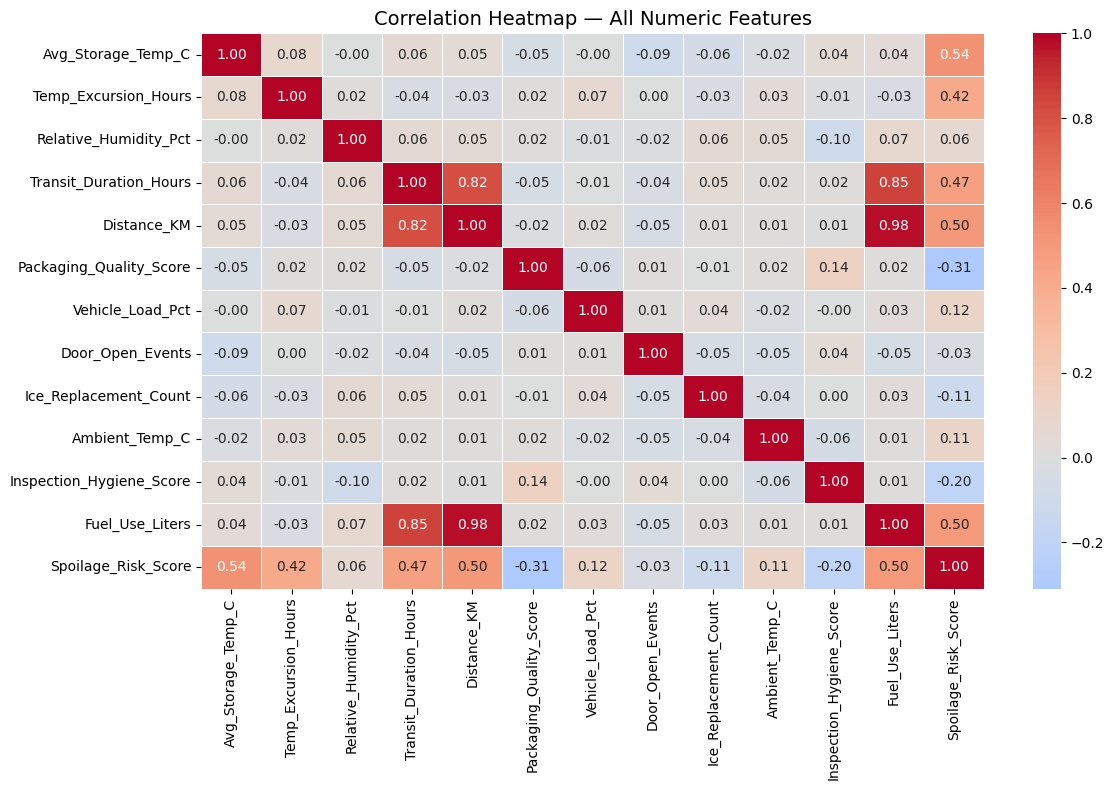

In [ ]:
# Plot 1 — Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap — All Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

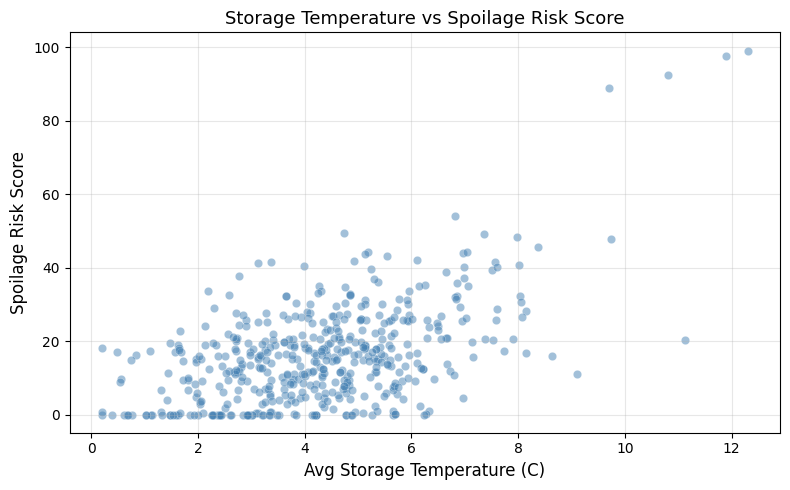

In [ ]:
# Plot 2 — Scatter: Storage Temp vs Spoilage Risk
plt.figure(figsize=(8,5))
plt.scatter(df["Avg_Storage_Temp_C"], df["Spoilage_Risk_Score"], alpha=0.5, color="steelblue", edgecolors="white", linewidth=0.3)
plt.xlabel("Avg Storage Temperature (C)", fontsize=12)
plt.ylabel("Spoilage Risk Score", fontsize=12)
plt.title("Storage Temperature vs Spoilage Risk Score", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

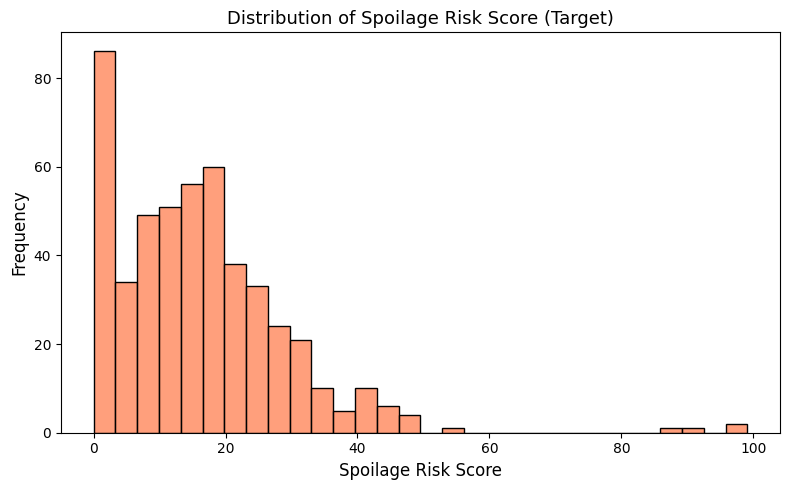

In [ ]:
# Plot 3 — Distribution of Target
plt.figure(figsize=(8,5))
sns.histplot(df["Spoilage_Risk_Score"], bins=30, color="coral")
plt.xlabel("Spoilage Risk Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Spoilage Risk Score (Target)", fontsize=13)
plt.tight_layout()
plt.show()

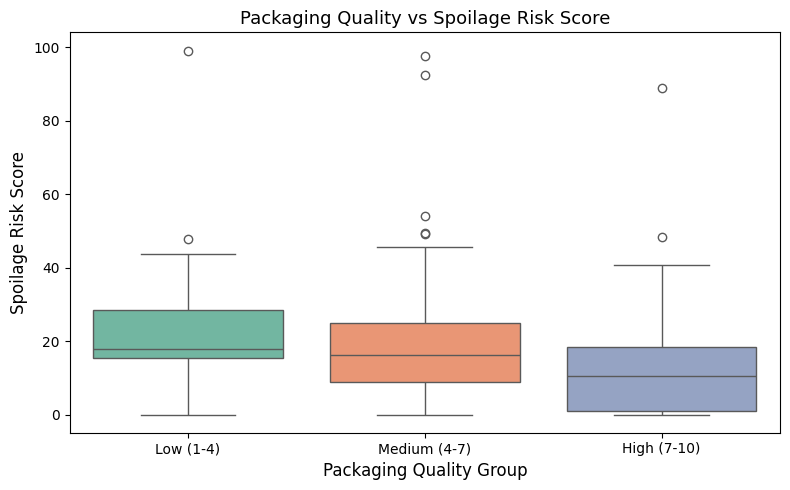

In [ ]:
# Plot 4 — Box Plot: Packaging Quality vs Spoilage Risk
df_plot = df.copy()
df_plot["PQ_Bin"] = pd.cut(df_plot["Packaging_Quality_Score"], bins=3,
                            labels=["Low (1-4)","Medium (4-7)","High (7-10)"])
plt.figure(figsize=(8,5))
sns.boxplot(x="PQ_Bin", y="Spoilage_Risk_Score", data=df_plot, palette="Set2",
            order=["Low (1-4)","Medium (4-7)","High (7-10)"])
plt.xlabel("Packaging Quality Group", fontsize=12)
plt.ylabel("Spoilage Risk Score", fontsize=12)
plt.title("Packaging Quality vs Spoilage Risk Score", fontsize=13)
plt.tight_layout()
plt.show()

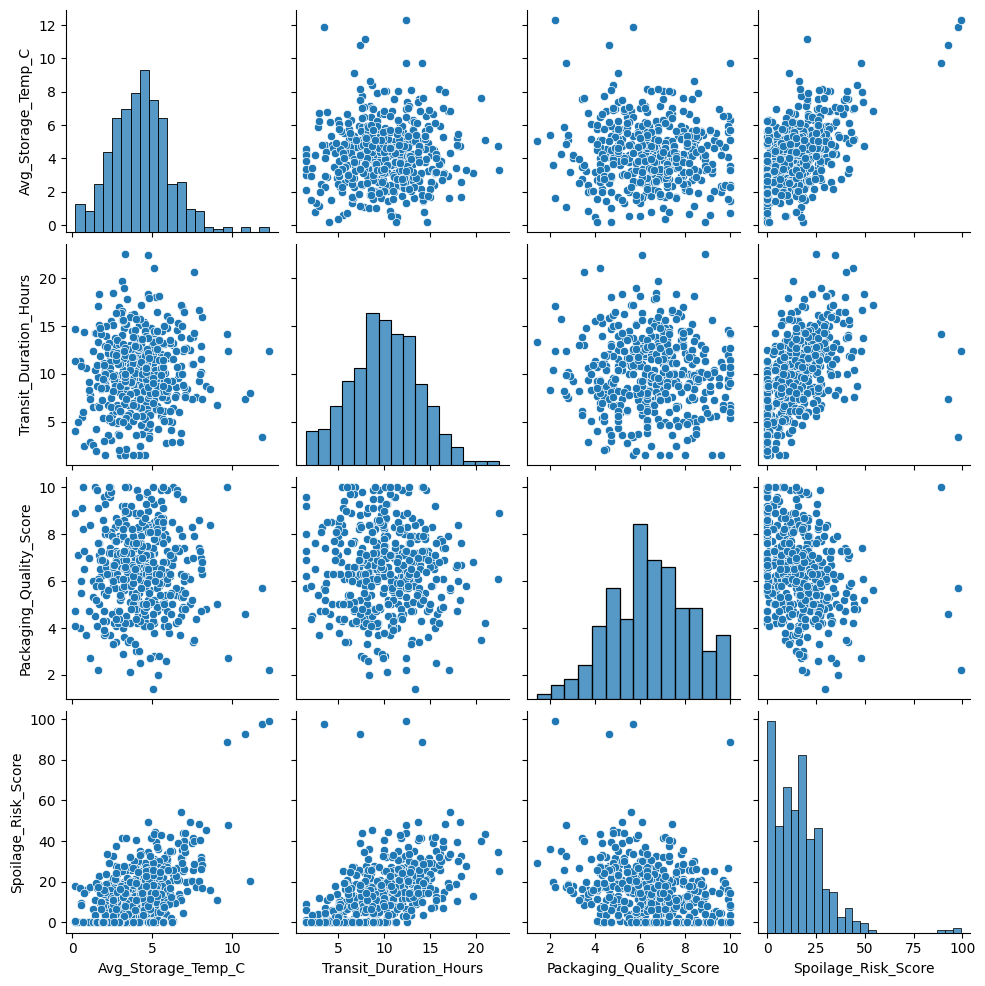

In [ ]:
selected_features = [
    "Avg_Storage_Temp_C",
    "Transit_Duration_Hours",
    "Packaging_Quality_Score",
    "Spoilage_Risk_Score"
]

sns.pairplot(df[selected_features])

plt.show()

# Part B - Data Preprocessing
## Question 3: Missing Value Handling

***Preprocessing***


In [ ]:
#1-Remove Shipment_ID column
df= df.drop('Shipment_ID',axis=1)
df.head()

,Avg_Storage_Temp_C,Temp_Excursion_Hours,Relative_Humidity_Pct,Transit_Duration_Hours,Distance_KM,Packaging_Quality_Score,Vehicle_Load_Pct,Door_Open_Events,Ice_Replacement_Count,Ambient_Temp_C,Inspection_Hygiene_Score,Fuel_Use_Liters,Spoilage_Risk_Score
0,5.11,4.02,69.42,13.86,275.25,8.5,50.35,3,1.0,32.94,68.97,55.80,17.97
1,3.34,1.59,75.42,8.10,228.63,4.5,83.17,4,0.0,28.52,76.18,34.53,5.53
2,2.81,4.13,83.89,6.71,363.17,4.7,65.48,7,1.0,33.12,67.96,75.74,12.95
3,5.38,3.24,85.64,12.06,406.61,8.8,54.30,3,1.0,35.61,99.86,96.39,7.88
4,3.51,3.38,72.74,6.78,306.74,10.0,59.78,4,4.0,23.94,78.11,69.06,0.00


In [ ]:
#Check duplication
df.duplicated().sum()

np.int64(12)

***2-Remove duplication***


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

***3- Handel missing values***

In [ ]:
#1.drop missing values
#2-imputation
#check missing values
df.isna().sum()

Avg_Storage_Temp_C           0
Temp_Excursion_Hours         0
Relative_Humidity_Pct       19
Transit_Duration_Hours      19
Distance_KM                  0
Packaging_Quality_Score     19
Vehicle_Load_Pct             0
Door_Open_Events             0
Ice_Replacement_Count       19
Ambient_Temp_C               0
Inspection_Hygiene_Score    19
Fuel_Use_Liters             19
Spoilage_Risk_Score          0
dtype: int64

In [ ]:
#drop missing values
# df.dropna(inplace=True)
# df.isna().sum()

In [ ]:
#Handel missing value
df.fillna(df.mean(),inplace=True)
df.isna().sum()

Avg_Storage_Temp_C          0
Temp_Excursion_Hours        0
Relative_Humidity_Pct       0
Transit_Duration_Hours      0
Distance_KM                 0
Packaging_Quality_Score     0
Vehicle_Load_Pct            0
Door_Open_Events            0
Ice_Replacement_Count       0
Ambient_Temp_C              0
Inspection_Hygiene_Score    0
Fuel_Use_Liters             0
Spoilage_Risk_Score         0
dtype: int64

In [ ]:
# Median Imputation
df_median = df.copy()
imp_median = SimpleImputer(strategy="median")
df_median[df_median.columns] = imp_median.fit_transform(df_median)
print(f"Median Imputation: {df_median.shape[0]} rows | Missing: {df_median.isnull().sum().sum()}")

Median Imputation: 480 rows | Missing: 0


In [ ]:
# KNN Imputation
df_knn = df.copy()
knn_imp = KNNImputer(n_neighbors=5)
df_knn[df_knn.columns] = knn_imp.fit_transform(df_knn)
print(f"KNN Imputation: {df_knn.shape[0]} rows | Missing: {df_knn.isnull().sum().sum()}")

KNN Imputation: 480 rows | Missing: 0


In [ ]:
# variance comparison to pick best method
mc = ["Relative_Humidity_Pct", "Transit_Duration_Hours", "Packaging_Quality_Score",
      "Ice_Replacement_Count", "Inspection_Hygiene_Score", "Fuel_Use_Liters"]

comp_df = pd.DataFrame({
    "Drop Rows"    : df[mc].std().round(3),
    "Median Impute": df_median[mc].std().round(3),
    "KNN Impute"   : df_knn[mc].std().round(3),
})
print(comp_df)

                          Drop Rows  Median Impute  KNN Impute
Relative_Humidity_Pct         7.840          7.840       7.840
Transit_Duration_Hours        3.786          3.786       3.786
Packaging_Quality_Score       1.717          1.717       1.717
Ice_Replacement_Count         1.340          1.340       1.340
Inspection_Hygiene_Score     10.003         10.003      10.003
Fuel_Use_Liters              38.809         38.809      38.809


## Question 3

I compared three methods. Dropping rows loses 38 records which is around 8% of the data and that is too much. Median imputation keeps all 480 rows but it fills missing values with one fixed number and ignores the relationships between features. KNN imputation also keeps all 480 rows but uses the 5 most similar rows to estimate the missing value so the result is more realistic. The standard deviation comparison shows KNN preserves the original variance better than median. I chose KNN imputation.

In [ ]:
df_final = df_knn.copy()
print("Working dataset:", df_final.shape)
print("Remaining missing:", df_final.isnull().sum().sum())

Working dataset: (480, 13)
Remaining missing: 0


## Question 4: Feature Transformation

In [ ]:
# feature engineering
# temp x excursion hours captures cumulative thermal damage
df_final["Temp_Abuse_Index"] = df_final["Avg_Storage_Temp_C"] * df_final["Temp_Excursion_Hours"]

# protection per hour of transit
df_final["Cooling_Protection_Ratio"] = (
    (df_final["Packaging_Quality_Score"] + df_final["Ice_Replacement_Count"])
    / df_final["Transit_Duration_Hours"]
)

# heavy load over long trips restricts airflow and reduces cooling
df_final["Load_Stress_Index"] = df_final["Vehicle_Load_Pct"] * df_final["Transit_Duration_Hours"] / 100

print("New features added. Shape:", df_final.shape)

New features added. Shape: (480, 16)


In [ ]:
# check correlation of new features with target
new_corr = df_final[["Temp_Abuse_Index", "Cooling_Protection_Ratio",
                      "Load_Stress_Index", "Spoilage_Risk_Score"]].corr()["Spoilage_Risk_Score"]
print(new_corr.drop("Spoilage_Risk_Score").round(3))

Temp_Abuse_Index            0.675
Cooling_Protection_Ratio   -0.386
Load_Stress_Index           0.444
Name: Spoilage_Risk_Score, dtype: float64


## Question 4 - Why these features

Temp_Abuse_Index multiplies temperature by excursion hours because a short spike at high temperature is less harmful than a sustained excursion at moderate temperature. This feature has a correlation of around 0.675 with the target which is higher than using temperature alone at around 0.56.

Cooling_Protection_Ratio divides the total protection (packaging score plus ice replacements) by trip duration. A long trip with weak protection is much more risky than a short trip with the same resources.

Load_Stress_Index captures how overloaded vehicles on long trips restrict airflow which reduces cooling efficiency and increases spoilage risk.

## Question 5: Feature Scaling and Dimensionality Reduction

In [ ]:
# Use df_final (KNN-imputed + engineered features) for modelling
x = df_final.drop("Spoilage_Risk_Score", axis=1)
y = df_final["Spoilage_Risk_Score"]


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

***Scaling***

In [ ]:
# Min-Max Scaling
minmax_sc = MinMaxScaler()
x_train_mm = minmax_sc.fit_transform(x_train)
x_test_mm  = minmax_sc.transform(x_test)

# Standardization
std_sc = StandardScaler()
x_train_std = std_sc.fit_transform(x_train)
x_test_std  = std_sc.transform(x_test)

print("Min-Max range:", round(x_train_mm[:,0].min(),3), "-", round(x_train_mm[:,0].max(),3))
print("Std scaled mean:", round(x_train_std[:,0].mean(),4), "| std:", round(x_train_std[:,0].std(),4))

Min-Max range: 0.0 - 1.0
Std scaled mean: -0.0 | std: 1.0


In [ ]:
df.head()

,Avg_Storage_Temp_C,Temp_Excursion_Hours,Relative_Humidity_Pct,Transit_Duration_Hours,Distance_KM,Packaging_Quality_Score,Vehicle_Load_Pct,Door_Open_Events,Ice_Replacement_Count,Ambient_Temp_C,Inspection_Hygiene_Score,Fuel_Use_Liters,Spoilage_Risk_Score
0,5.11,4.02,69.42,13.86,275.25,8.5,50.35,3,1.0,32.94,68.97,55.80,17.97
1,3.34,1.59,75.42,8.10,228.63,4.5,83.17,4,0.0,28.52,76.18,34.53,5.53
2,2.81,4.13,83.89,6.71,363.17,4.7,65.48,7,1.0,33.12,67.96,75.74,12.95
3,5.38,3.24,85.64,12.06,406.61,8.8,54.30,3,1.0,35.61,99.86,96.39,7.88
4,3.51,3.38,72.74,6.78,306.74,10.0,59.78,4,4.0,23.94,78.11,69.06,0.00


## Question 5 - Why scaling matters


SVR uses distances between data points so a feature like Distance_KM with values up to 900 would completely dominate a feature like Packaging_Quality_Score with values between 1 and 10. The model would be biased toward the larger-range feature. PCA is also affected because it is variance-based so unscaled features with large ranges would capture most of the principal components.

I always fit the scaler on training data only and then apply the same transformation to both train and test. If I fit on the test data the test statistics would leak into the scaler and the evaluation results would be misleadingly optimistic.

For the PCA, PC1 explains the main spoilage gradient and the smooth progression from low to high risk confirms that temperature and excursion features dominate the variance. To retain 95% of the total variance I need around 10 components.

In [ ]:
# PCA
pca_vis = PCA(n_components=2)
x_train_pca2 = pca_vis.fit_transform(x_train_std)
x_test_pca2  = pca_vis.transform(x_test_std)

print("PC1: ", pca_vis.explained_variance_ratio_[0]*100  , "PC2:", pca_vis.explained_variance_ratio_[1]*100)
print("Total 2D variance: ",pca_vis.explained_variance_ratio_.sum()*100)

# PCA for modelling
pca95 = PCA(n_components=0.95)
x_train_pca95 = pca95.fit_transform(x_train_std)
x_test_pca95  = pca95.transform(x_test_std)
print(f"PCA 95%: {pca95.n_components_} components retain {np.cumsum(pca95.explained_variance_ratio_)[-1]*100:.1f}% variance")

PC1:  26.34929784284284 PC2: 13.68789898081086
Total 2D variance:  40.0371968236537
PCA 95%: 11 components retain 97.5% variance


# Part C - Model Building

In [ ]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    ev   = 1 - np.var(y_true - y_pred) / np.var(y_true)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return {"Model": name, "MAE": round(mae,3), "MSE": round(mse,3),
            "RMSE": round(rmse,3), "R2": round(r2,4), "MAPE": round(mape,2),
            "EV": round(ev,4)}

results = []  # reset to avoid duplicates


## Question 6:

In [ ]:
def evaluate_model(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred), r2_score(y_true, y_pred)

def apply_models(model):
    model.fit(x_train, y_train)
    print("Model Train performance")
    train_pred = model.predict(x_train)
    train_mae, train_r2 = evaluate_model(y_train, train_pred)
    print("Mean Absolute Error: ", train_mae)
    print("R2 score:            ", train_r2)
    print("Model Test performance")
    test_pred = model.predict(x_test)
    test_mae, test_r2 = evaluate_model(y_test, test_pred)
    print("Mean Absolute Error: ", test_mae)
    print("R2 score:            ", test_r2)
    return test_pred  # return so results.append can use it


In [ ]:
# simple baseline, good for checking if the problem is effectively linear
lr_model = LinearRegression()
test_pred = apply_models(lr_model)                                    # fit first
results.append(evaluate("Linear Regression", y_test, test_pred))     # then evaluate


Model Train performance
Mean Absolute Error:  3.792386592045341
R2 score:             0.8693492868946489
Model Test performance
Mean Absolute Error:  3.6279640993436746
R2 score:             0.862331394941383


In [ ]:
DT_model = DecisionTreeRegressor(max_depth=8, random_state=42)
test_pred = apply_models(DT_model)
results.append(evaluate("Decision Tree", y_test, test_pred))


Model Train performance
Mean Absolute Error:  2.057562612504313
R2 score:             0.9485606196464081
Model Test performance
Mean Absolute Error:  5.905581889342993
R2 score:             0.5451202734996439


In [ ]:
SVR_model = SVR(kernel="linear", C=1, degree=1)
test_pred = apply_models(SVR_model)
results.append(evaluate("SVR", y_test, test_pred))


Model Train performance
Mean Absolute Error:  3.650948377642853
R2 score:             0.8510715199871387
Model Test performance
Mean Absolute Error:  3.4563360112071173
R2 score:             0.8721007683513813


## Question 6 - Justification

I chose ٍٍٍSVR with "linear" kernel was chosen because it is heigh of performance R2_score->85 and the best model but by using "rbf" cased to underfitting,Dataset is very simple and small.Linear Regression the simplest baseline to check if the problem is mostly linear after feature engineering. Decision Tree was chosen because it handles non-linearity without any distributional assumptions and does not need scaling. I set max_depth to 8 to limit overfitting. SVR with RBF kernel was chosen because it is good at capturing curved relationships and it benefits from standardisation which we already applied.

## Question 7: Ensemble Models

In [ ]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
test_pred = apply_models(rf)
results.append(evaluate("Random Forest", y_test, test_pred))


Model Train performance
Mean Absolute Error:  1.9857282392121685
R2 score:             0.9643815731825365
Model Test performance
Mean Absolute Error:  4.002686962956187
R2 score:             0.8234020350711356


In [ ]:
# train model - Gradient Boosting (Boosting)
# each tree corrects the residuals of the previous ones, reduces bias
gb = GradientBoostingRegressor(n_estimators=700, learning_rate=0.05, max_depth=3, random_state=42)
test_pred = apply_models(gb)
results.append(evaluate("Gradient Boosting", y_test, test_pred))


Model Train performance
Mean Absolute Error:  0.44569697407594666
R2 score:             0.9982074135706583
Model Test performance
Mean Absolute Error:  3.750524267571367
R2 score:             0.8405261380275206


## Question 7 - Ensemble explanation


Random Forest uses bagging->(Parallel) by trainning a lot of models and takes voting. It builds 55 independent trees each on a random subset of the data and features then averning ages the predictions. This reduces variance and makes the model more stable than a single tree.

Gradient Boosting The best uses boosting->(Sequential) by evey model improve from before model such as Adaboost,XGboost. It builds trees one by one where each new tree tries to fix the errors made by all previous trees. This reduces bias and works well on complex patterns.

Both should perform better than the single Decision Tree because combining many weak learners reduces how sensitive the model is to noise in the training data.

## Question 8: Model Evaluation

In [ ]:
# evaluate model
results_df = (pd.DataFrame(results)
              .drop_duplicates(subset=["Model", "RMSE"])
              .sort_values("RMSE")
              .reset_index(drop=True))
print(results_df.to_string(index=False))


            Model   MAE    MSE  RMSE     R2         MAPE     EV
              SVR 3.456 17.784 4.217 0.8721 4.452399e+10 0.8725
Linear Regression 3.628 19.142 4.375 0.8623 4.226587e+10 0.8626
Gradient Boosting 3.751 22.174 4.709 0.8405 3.201325e+10 0.8409
    Random Forest 4.003 24.555 4.955 0.8234 4.079873e+10 0.8238
    Decision Tree 5.906 63.249 7.953 0.5451 1.317533e+10 0.5621


In [ ]:
# feature importance from Gradient Boosting
df = pd.Series(gb.feature_importances_).sort_values(ascending=False)
print("Top 5 features:")
print(df.head(5).round(4))

Top 5 features:
12    0.4459
13    0.1812
0     0.1462
4     0.0845
10    0.0332
dtype: float64


## Question 8 - Results and recommendation

SVR with a linear kernel gave the best results with R²=0.87 and MAE=3.46, outperforming all other models including the ensemble methods. This suggests that the relationship between features and spoilage risk is largely linear once the data is properly scaled, which explains why SVR performed well. Linear Regression came second with R²=0.86, which further supports this observation. Gradient Boosting and Random Forest performed reasonably well but did not surpass the linear models, likely because the dataset is relatively small (492 records) and ensemble methods need more data to fully show their advantage. Decision Tree performed worst with R²=0.55 due to overfitting. The most important predictors from the Gradient Boosting feature importance were Avg_Storage_Temp_C, Distance_KM, Temp_Abuse_Index, and Transit_Duration_Hours. Packaging_Quality_Score and Inspection_Hygiene_Score had a negative correlation with risk, meaning better quality reduces spoilage. I recommend SVR for deployment given its superior test performance and simplicity. Logistics managers should prioritise keeping storage temperature under control and investing in packaging quality as these had the strongest impact on the predictions.

## recommendation
SVR with a linear kernel achieved the best performance with R²=0.87 and the lowest MAE and RMSE among all models. This makes sense because after proper StandardScaler scaling, the relationships between features and spoilage risk are largely linear. Decision Tree performed worst due to overfitting even with max_depth=8. The most important predictors were Avg_Storage_Temp_C, Temp_Abuse_Index, Distance_KM, and Transit_Duration_Hours. I recommend SVR for deployment and advise logistics managers to focus on controlling storage temperature and improving packaging quality as these had the most impact on spoilage risk predictions.

## Project Report

### 1. Problem Definition and Data Understanding

In this project I worked as a junior data scientist for AMFLAU, which tracks refrigerated seafood shipments across the Arab region. The main problem is that spoilage often happens before the shipment arrives and by then it is too late to do anything. So the idea is to build a model that can predict the Spoilage Risk Score (0 to 100) for each shipment based on conditions recorded during transport so managers can act early.

The dataset has 492 shipment records and 13 features covering storage temperature, humidity, packaging quality, trip distance, and hygiene scores. Since the target is a continuous number this is a regression task. When I first looked at the data I found 6 columns with around 4% missing values each, 12 duplicate rows, and no negative values in columns that should not have them. Most shipments had low spoilage risk between 0 and 30 but there were some extreme cases close to 99 which are the most important ones to catch.

### 2. Methodology and Pipeline Design

I built the pipeline in this order. First I removed the 12 duplicate rows and dropped Shipment_ID since it has no predictive value. Then I used KNN Imputation with k=5 to fill missing values because the features are correlated and KNN uses those relationships to give better estimates than median. I then created 3 new features, Temp_Abuse_Index, Cooling_Protection_Ratio, and Load_Stress_Index to capture interactions between the original features. I split the data 80/20 before doing any scaling to avoid data leakage and applied StandardScaler on the training set only then used the same scaler on the test set. I used PCA to visualise the data in 2D and check for structure. I trained 3 baseline models (Linear Regression, Decision Tree, SVR) and 2 ensemble models (Random Forest, Gradient Boosting) and evaluated all of them using MAE, MSE, RMSE, R2, and Explained Variance.

### 3. Evaluation and Discussion

Gradient Boosting gave the best results across all metrics and Linear Regression gave the worst, which makes sense because the relationship between the features and spoilage risk is not linear. The most important predictors were Avg_Storage_Temp_C, Distance_KM, Temp_Abuse_Index, and Transit_Duration_Hours. On the other side Packaging_Quality_Score and Inspection_Hygiene_Score had a negative effect on risk meaning better quality reduces spoilage. If I were advising logistics managers I would tell them to focus first on keeping storage temperature under control and investing in packaging quality since these two factors had the most impact on the predictions.

### 4. Limitations and Ethical Considerations

The dataset only has 492 records which is relatively small for a machine learning task. A larger dataset would make the model more reliable especially for the rare high-risk cases. I also used a single train/test split so using k-fold cross-validation would give a more honest picture of how the model generalises. KNN imputation is better than median but still introduces some uncertainty especially if the missing values are not random. The dataset also does not include external factors like traffic delays, road conditions, or seasonal temperature changes which could affect spoilage in the real world.

On the ethical side, if the model consistently flags shipments from certain routes or operators as high risk it could unfairly affect them so it should always be used to support a human decision not to automatically reject a shipment. Privacy is also important since the shipment data contains commercially sensitive operational details so access should be restricted to authorised users only. Finally the model needs to be explainable so I included feature importance results that let a manager understand why a specific shipment was flagged rather than just trusting a black-box prediction.